<a href="https://colab.research.google.com/github/murtaza-zangejo/CodeAlpha-Handwritten-Character-Recognition-/blob/main/Handwritten_Character_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Handwritten Character Recognition Using Deep Learning (CNN)
Objective

Develop a Convolutional Neural Network (CNN) that recognizes handwritten digits, letters, or characters from grayscale images with high accuracy.

#Step 01: Import Required Libraries

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Step 02: Loading Dataset
For this project we have used MNIST downloaded from https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz

MNIST Dataset

70,000 handwritten digit images

Training: 60,000

Testing: 10,000

Image size: 28×28 grayscale

Classes: 10 (0–9).

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# Step 03: Exploratory Data Analysis EDA
Dataset shape and image samples

In [3]:
print(X_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


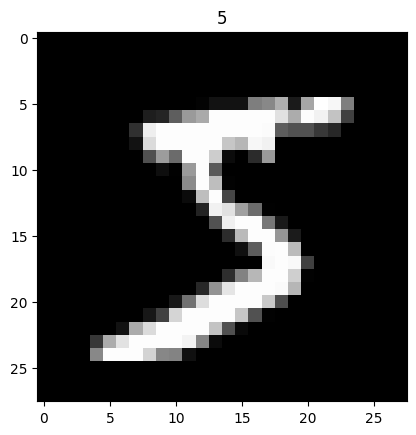

In [4]:
plt.imshow(X_train[0], cmap='gray')
plt.title(y_train[0])
plt.show()

# Step 04: Data Preprocessing

In [5]:
#Normalize Images
X_train = X_train / 255.0
X_test = X_test / 255.0

In [6]:
#Reshape Images into 4D
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [7]:
#One Hot Encoding labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Data Augmentation

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

datagen.fit(X_train)

#Step 05: Building CNN Model

In [9]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))

model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))

model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Step 06: Compiling the Model

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#Step 07: Model Training

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.9314 - loss: 0.2261 - val_accuracy: 0.9812 - val_loss: 0.0633
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9755 - loss: 0.0840 - val_accuracy: 0.9838 - val_loss: 0.0503
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 56s 37ms/step - accuracy: 0.9805 - loss: 0.0639 - val_accuracy: 0.9890 - val_loss: 0.0394
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 90s 43ms/step - accuracy: 0.9847 - loss: 0.0513 - val_accuracy: 0.9903 - val_loss: 0.0394
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 35ms/step - accuracy: 0.9870 - loss: 0.0417 - val_accuracy: 0.9877 - val_loss: 0.0441
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 35ms/step - accuracy: 0.9892 - loss: 0.0348 - val_accuracy: 0.9891 - val_loss: 0.0384
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 54s 36ms/step - accuracy: 0.9906 - loss: 0.0308 - val_accuracy: 0.9909 - val_loss: 0.0371
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 86s 38ms/step - accuracy: 0.9914 -

#Step 08: Evaluate Model

In [12]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9911 - loss: 0.0303
Accuracy: 0.991100013256073


#Step 09: Performance Metric

In [13]:
#Generate predictions
y_pred = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [14]:
#Convert predictions
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

In [15]:
#Generate Classification Report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      0.98      0.99       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [33]:
#Generate Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm

array([[ 976,    0,    1,    1,    0,    0,    1,    0,    1,    0],
       [   0, 1132,    0,    0,    0,    0,    1,    2,    0,    0],
       [   1,    0, 1024,    1,    1,    0,    1,    4,    0,    0],
       [   0,    0,    1, 1005,    0,    2,    0,    1,    1,    0],
       [   0,    0,    0,    0,  967,    0,    3,    1,    3,    8],
       [   2,    0,    1,    8,    0,  876,    2,    0,    0,    3],
       [   1,    2,    0,    0,    2,    1,  952,    0,    0,    0],
       [   0,    3,    2,    1,    1,    0,    0, 1019,    1,    1],
       [   1,    0,    1,    1,    0,    0,    0,    2,  966,    3],
       [   0,    0,    0,    0,    4,    3,    0,    5,    3,  994]])

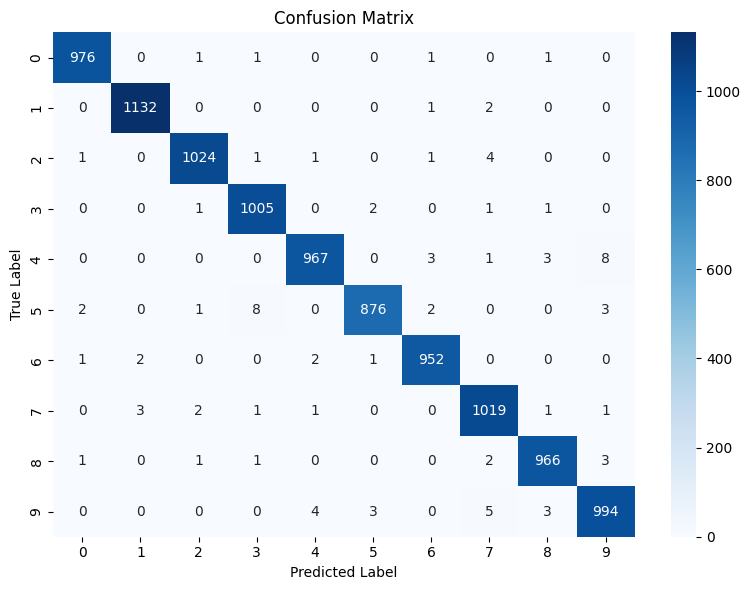

In [36]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()

#Step 10: Visualizations

**Class distribution (Bar chart)**

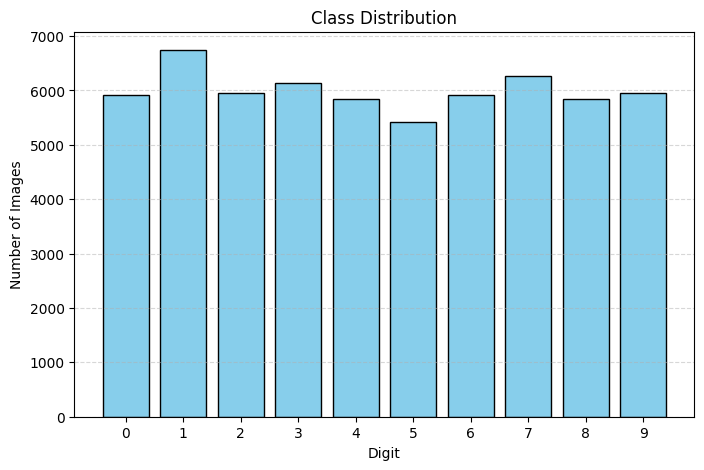

In [42]:
import matplotlib.pyplot as plt
import numpy as np

classes, counts = np.unique(np.argmax(y_train, axis=1), return_counts=True)

plt.figure(figsize=(8,5))
plt.bar(classes, counts, color='skyblue', edgecolor='black')
plt.title("Class Distribution")
plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.xticks(classes)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Sample handwritten images**

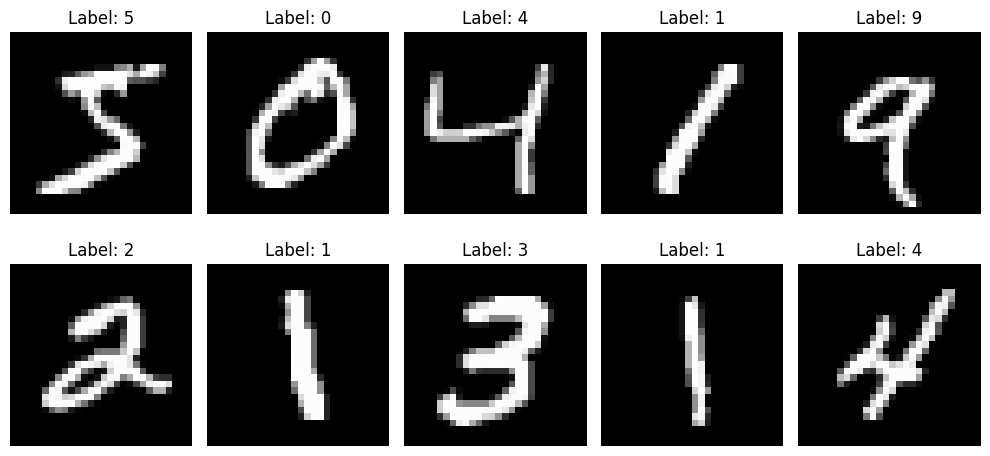

In [43]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i].reshape(28,28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis('off')

plt.tight_layout()
plt.show()

**Training Accuracy vs Validation Accuracy**

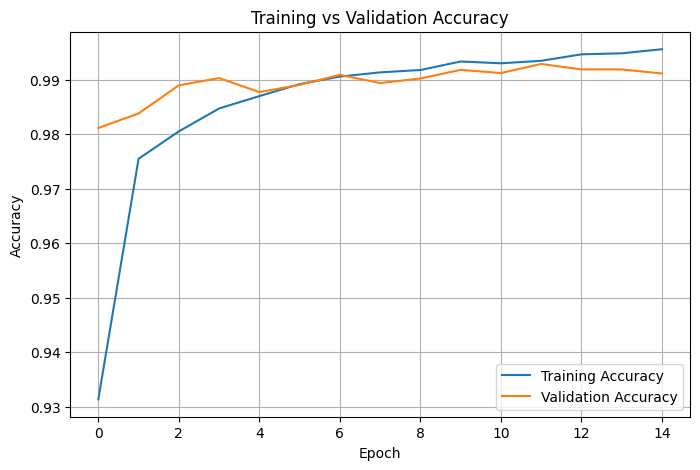

In [44]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

**Training Loss vs Validation Loss**

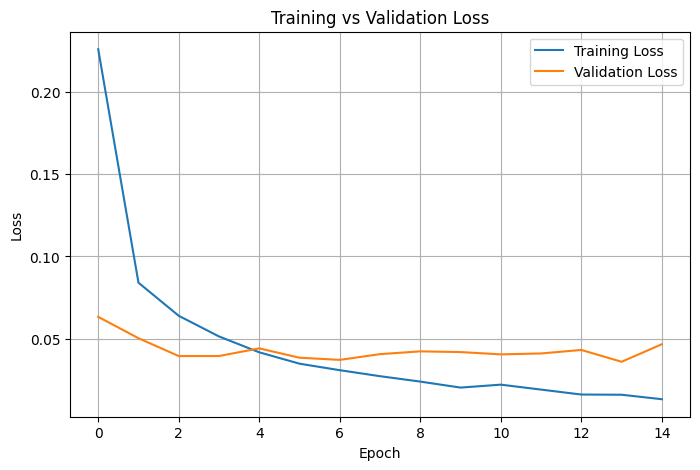

In [45]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

**Confusion Matrix (Heatmap)**

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


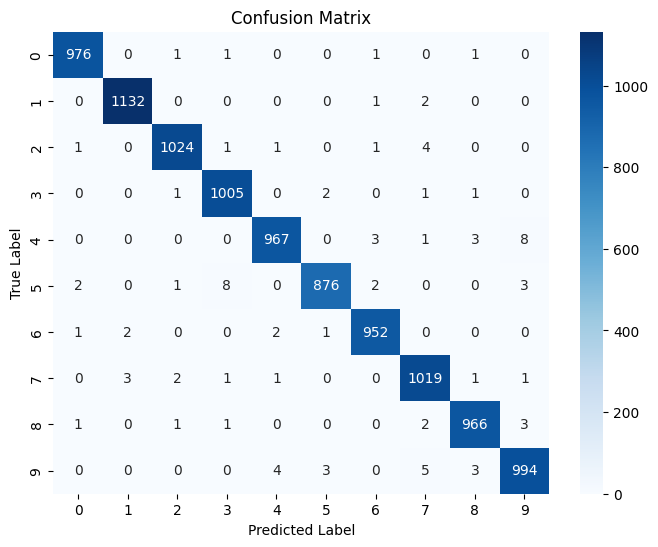

In [46]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

**Prediction Probability Chart**

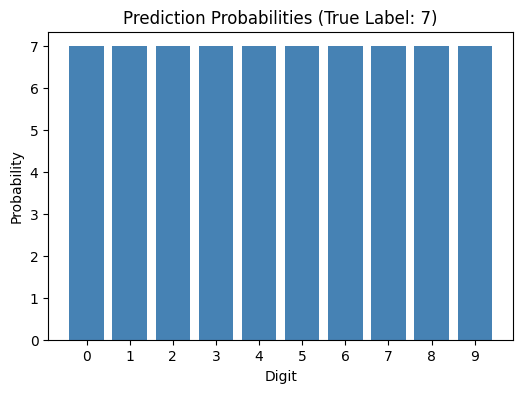

In [41]:
sample = 0

plt.figure(figsize=(6,4))

plt.bar(
    range(10),
    y_pred[sample],
    color='steelblue'
)

plt.xticks(range(10))
plt.xlabel("Digit")
plt.ylabel("Probability")
plt.title(f"Prediction Probabilities (True Label: {y_true[sample]})")

plt.show()

#Step 11: Save Model

In [17]:
model.save("handwritten_character_recognition.keras")

#Step 12: Test on New Image

##Load image

In [27]:
from tensorflow.keras.preprocessing import image

img = image.load_img(
    "digit.png",
    color_mode='grayscale',
    target_size=(28,28)
)

In [28]:
#Convert to Array
img = image.img_to_array(img)

In [29]:
#Image reshape
img = img / 255.0
img = img.reshape(1,28,28,1)

## Prediction

In [31]:
prediction = model.predict(img)

predicted_digit = np.argmax(prediction)

print(predicted_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
5


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
True Digit: 5
Predicted Digit: 5


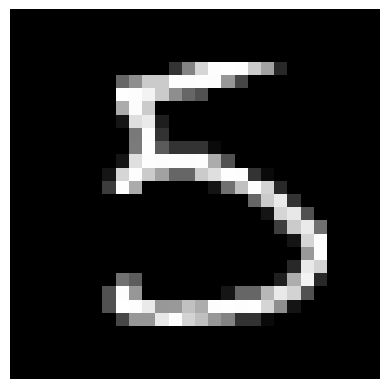

In [30]:
index = 15

img = X_test[index].reshape(1,28,28,1)

prediction = model.predict(img)

predicted_digit = np.argmax(prediction)

true_digit = np.argmax(y_test[index])

print("True Digit:", true_digit)
print("Predicted Digit:", predicted_digit)

plt.imshow(X_test[index].reshape(28,28), cmap="gray")
plt.axis("off")
plt.show()